# Train, Validation and Test Splits

This notebook builds a stratified three-way split with two calls to `train_test_split`, checks the class proportions per split and uses the validation set to choose `k` in k-NN before touching the test set once.

## Import Required Libraries

Import pandas and the scikit-learn tools used for splitting and modelling.

In [1]:
# Import the required libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Define the course colour palette.
colors = ["#179E86", "#2580B7", "#9EBE5B", "#C03B26", "#44546A"]

## Load the Dataset

Load the Wine dataset and keep the class labels to control the split proportions.

In [2]:
# Load the Wine dataset.
wine = load_wine()
X, y = wine.data, wine.target
print(f"Total instances: {X.shape[0]}")
print(f"Class counts: {np.bincount(y)}")

Total instances: 178
Class counts: [59 71 48]


## Two-Step Three-Way Split

First carve out the test set, then split the remainder into training and validation, stratifying at each step.

In [3]:
# First split off the test set.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Then split the remainder into train and validation.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp,
    random_state=42)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, "
      f"Test: {X_test.shape[0]}")

Train: 106, Val: 36, Test: 36


## Class Proportions per Split

Stratification keeps the class proportions almost identical across the three splits.

In [4]:
# Build a table of class proportions for each split.
def proportions(labels):
    counts = np.bincount(labels, minlength=3)
    return counts / counts.sum()

table = pd.DataFrame({
    "train": proportions(y_train),
    "val": proportions(y_val),
    "test": proportions(y_test),
}, index=wine.target_names)
table.round(3)

,train,val,test
class_0,0.330,0.333,0.333
class_1,0.406,0.389,0.389
class_2,0.264,0.278,0.278


## Selecting k on the Validation Set

We scale the features and evaluate several values of `k` on the validation set only, never on the test set.

In [5]:
# Scale features using training statistics only.
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# Evaluate a range of k on the validation set.
ks = range(1, 16)
val_scores = []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    val_scores.append(knn.score(X_val_s, y_val))

best_k = list(ks)[int(np.argmax(val_scores))]
print(f"Best k on validation: {best_k}")

Best k on validation: 7


## Visualising the Validation Search

Plotting validation accuracy against `k` shows which neighbourhood size generalises best.

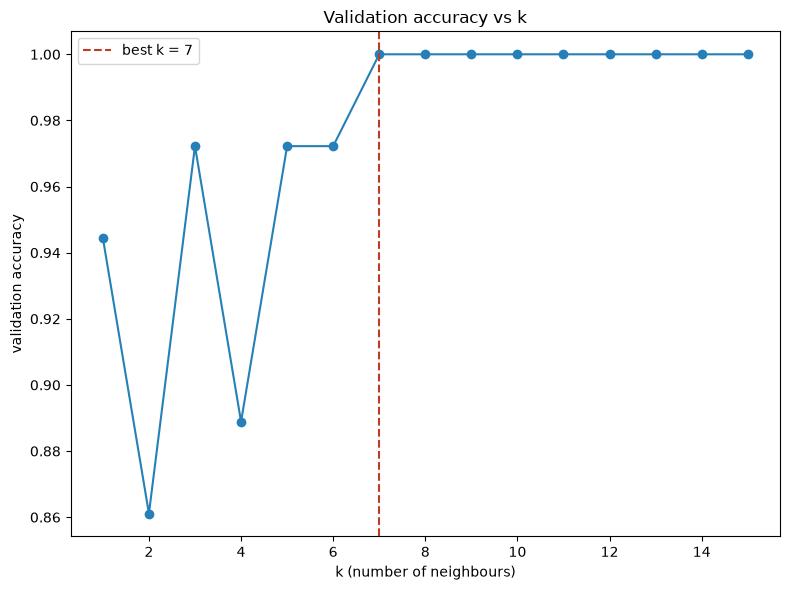

In [6]:
# Plot validation accuracy as a function of k.
plt.figure(figsize=(8, 6))
plt.plot(list(ks), val_scores, marker="o", color=colors[1])
plt.axvline(best_k, color=colors[3], linestyle="--",
            label=f"best k = {best_k}")
plt.title("Validation accuracy vs k")
plt.xlabel("k (number of neighbours)")
plt.ylabel("validation accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## Opening the Test Set Once

Only after `k` is fixed do we retrain on train plus validation and report the test accuracy a single time.

In [7]:
# Retrain with the chosen k and evaluate on the test set once.
X_fit = np.vstack([X_train_s, X_val_s])
y_fit = np.concatenate([y_train, y_val])
final = KNeighborsClassifier(n_neighbors=best_k)
final.fit(X_fit, y_fit)
print(f"Final test accuracy: {final.score(X_test_s, y_test):.3f}")

Final test accuracy: 1.000


## Summary

- **Three-way split**: two `train_test_split` calls give train, validation and test sets.
- **Stratify**: preserves class proportions in every split.
- **Validation set**: used to tune hyperparameters such as `k`.
- **Test set**: opened only once, at the very end, for an unbiased estimate.